In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import os
# import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from tqdm import tqdm


In [10]:
# Set directories
base_dir = "/Users/sethbushinsky/"
data_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Datasets/"
home_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/"
manuscript_dir = home_dir + "Manuscripts/2025_01 BGC Argo Plus Dataset Creation/"
manuscript_figs = manuscript_dir + "Figures/"
group_manuscript_figs = manuscript_dir + "Dataset paper group folder/Figures/" 
argo_path = data_dir + "Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/"
processed_path = argo_path + "../processed/"
plot_ver = 'v_202603'

## Bottom Hook Example

In [31]:

# file = '6901182_Sprof_flags_mode_only.nc'
file = '6901181_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 292MB
Dimensions:                                       (N_PROF: 494, N_PARAM: 12,
                                                   N_CALIB: 1, N_LEVELS: 1378)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/175)
    DATA_TYPE                                     object 8B b'Argo synthetic ...
    FORMAT_VERSION                                object 8B b'1.0 '
    HANDBOOK_VERSION                              object 8B b'1.2 '
    REFERENCE_DATE_TIME                           object 8B b'19500101000000'
    DATE_CREATION                                 object 8B b'20230816155347'
    DATE_UPDATE                                   object 8B b'20230816155347'
    ...                                            ...
    DOWN_IRRADIANCE490_profile_mode               (N_PROF) float64 4kB 0.0 .....
    DOWNWELLING_PAR_profile_mode                  (N_PROF) float64 4kB 0.0 .....
    CHLA_profile_mode                             (N_PROF) float64 4kB 1.0 .....
    CHLA_FLUORESCENCE_profile_mode                (N_PROF) float64 4kB 0.0 .....
    BBP700_profile_mode                           (N_PROF) float64 4kB 1.0 .....
    BBP532_profile_mode                           (N_PROF) float64 4kB 0.0 .....
Attributes:
    title:                Argo float vertical profile
    institution:          BODC
    source:               Argo float
    history:              2023-08-16T15:53:47Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.15 (version 09.06.2022 for ARGO_simplified_profile)

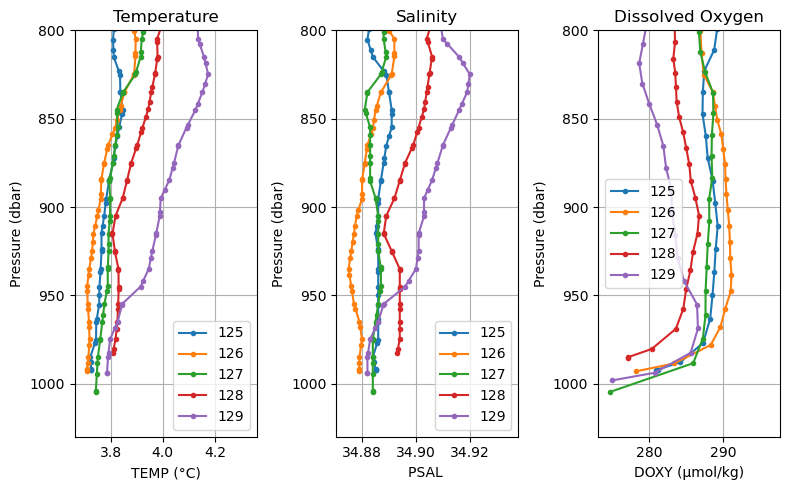

In [45]:
profile_range = np.arange(125, 130)
pressure_lims = [1030, 800]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '(°C)', 'PSAL': '', 'DOXY': '(µmol/kg)'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(8, 5))


filename = 'Bottom_Hook_Example_Float_' + file.split('_')[0] + '_' + plot_ver
for i, var in enumerate(variables):
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    ax1.set_title(f'{var_full_names[var]}')
    ax1.set_xlabel(f'{var} {units[var]}')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(manuscript_figs + filename + '.png', dpi=300)


## Surface measurement example

In [52]:

# file = '6901182_Sprof_flags_mode_only.nc'
file = '6901774_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 131MB
Dimensions:                                       (N_PROF: 218, N_PARAM: 12,
                                                   N_CALIB: 1, N_LEVELS: 1400)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/175)
    DATA_TYPE                                     object 8B b'Argo synthetic ...
    FORMAT_VERSION                                object 8B b'1.0 '
    HANDBOOK_VERSION                              object 8B b'1.2 '
    REFERENCE_DATE_TIME                           object 8B b'19500101000000'
    DATE_CREATION                                 object 8B b'20241224123007'
    DATE_UPDATE                                   object 8B b'20241224123007'
    ...                                            ...
    DOWN_IRRADIANCE490_profile_mode               (N_PROF) float64 2kB 0.0 .....
    DOWNWELLING_PAR_profile_mode                  (N_PROF) float64 2kB 0.0 .....
    CHLA_profile_mode                             (N_PROF) float64 2kB 1.0 .....
    CHLA_FLUORESCENCE_profile_mode                (N_PROF) float64 2kB 0.0 .....
    BBP700_profile_mode                           (N_PROF) float64 2kB 1.0 .....
    CDOM_profile_mode                             (N_PROF) float64 2kB 0.0 .....
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-24T12:30:07Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

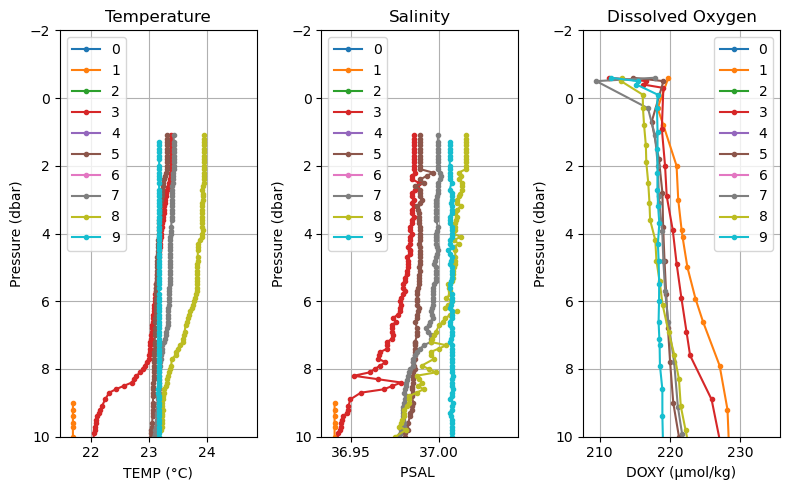

In [53]:
profile_range = np.arange(0, 10)
pressure_lims = [10, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '(°C)', 'PSAL': '', 'DOXY': '(µmol/kg)'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(8, 5))


filename = 'Surface_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
for i, var in enumerate(variables):
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    ax1.set_title(f'{var_full_names[var]}')
    ax1.set_xlabel(f'{var} {units[var]}')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(manuscript_figs + filename + '.png', dpi=300)


## ML "GOO" example

In [6]:

# file = '6901182_Sprof_flags_mode_only.nc'
file = '5905372_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 28MB
Dimensions:                                      (N_PROF: 157, N_PARAM: 9,
                                                  N_CALIB: 1, N_LEVELS: 560)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/142)
    DATA_TYPE                                    object 8B b'Argo synthetic p...
    FORMAT_VERSION                               object 8B b'1.0 '
    HANDBOOK_VERSION                             object 8B b'1.2 '
    REFERENCE_DATE_TIME                          object 8B b'19500101000000'
    DATE_CREATION                                object 8B b'20241223152044'
    DATE_UPDATE                                  object 8B b'20241223152044'
    ...                                           ...
    DOXY_profile_mode                            (N_PROF) float64 1kB 2.0 ......
    CHLA_profile_mode                            (N_PROF) float64 1kB 1.0 ......
    CHLA_FLUORESCENCE_profile_mode               (N_PROF) float64 1kB 1.0 ......
    BBP700_profile_mode                          (N_PROF) float64 1kB 1.0 ......
    PH_IN_SITU_TOTAL_profile_mode                (N_PROF) float64 1kB 2.0 ......
    NITRATE_profile_mode                         (N_PROF) float64 1kB 2.0 ......
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-12-23T15:20:44Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

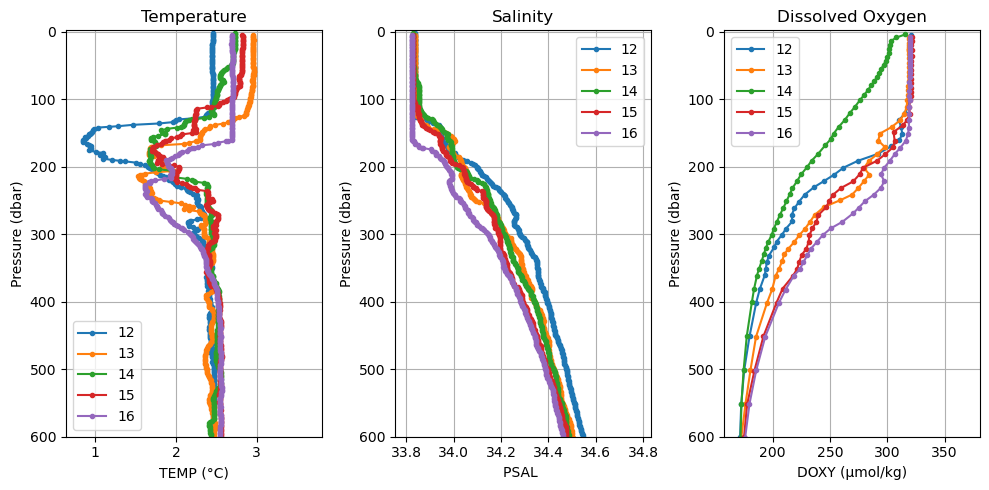

In [11]:
profile_range = np.arange(12, 17)
pressure_lims = [600, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '(°C)', 'PSAL': '', 'DOXY': '(µmol/kg)'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(10, 5))


filename = 'ML_Goo_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
for i, var in enumerate(variables):
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    ax1.set_title(f'{var_full_names[var]}')
    ax1.set_xlabel(f'{var} {units[var]}')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(group_manuscript_figs + filename + '.png', dpi=300)


## spike example

In [16]:

# file = '6901182_Sprof_flags_mode_only.nc'
file = '5904844_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 36MB
Dimensions:                                      (N_PROF: 199, N_PARAM: 9,
                                                  N_CALIB: 1, N_LEVELS: 560)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/142)
    DATA_TYPE                                    object 8B b'Argo synthetic p...
    FORMAT_VERSION                               object 8B b'1.0 '
    HANDBOOK_VERSION                             object 8B b'1.2 '
    REFERENCE_DATE_TIME                          object 8B b'19500101000000'
    DATE_CREATION                                object 8B b'20241221120537'
    DATE_UPDATE                                  object 8B b'20241221120537'
    ...                                           ...
    DOXY_profile_mode                            (N_PROF) float64 2kB 2.0 ......
    CHLA_profile_mode                            (N_PROF) float64 2kB 1.0 ......
    CHLA_FLUORESCENCE_profile_mode               (N_PROF) float64 2kB 1.0 ......
    BBP700_profile_mode                          (N_PROF) float64 2kB 1.0 ......
    PH_IN_SITU_TOTAL_profile_mode                (N_PROF) float64 2kB 2.0 ......
    NITRATE_profile_mode                         (N_PROF) float64 2kB 2.0 ......
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-12-21T12:05:37Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

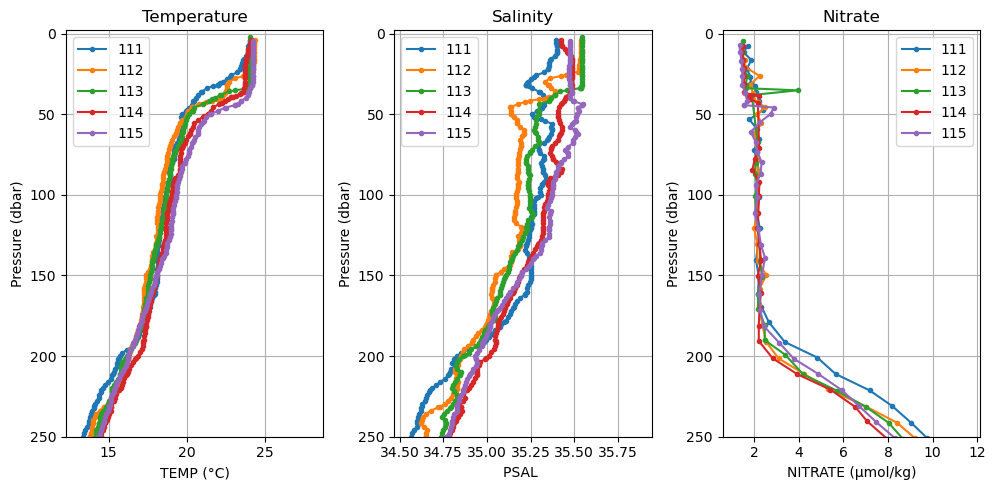

In [18]:
profile_range = np.arange(111, 116)
pressure_lims = [250, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'NITRATE']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Salinity', 'DOXY': 'Dissolved Oxygen', 'NITRATE': 'Nitrate'}
units = {'TEMP': '(°C)', 'PSAL': '', 'DOXY': '(µmol/kg)', 'NITRATE': '(µmol/kg)'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(10, 5))


filename = 'Spike_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
for i, var in enumerate(variables):
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    ax1.set_title(f'{var_full_names[var]}')
    ax1.set_xlabel(f'{var} {units[var]}')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(group_manuscript_figs + filename + '.png', dpi=300)
